# Figure 2 — Mobility diversity vs. cost across U.S. urban areas

Reproduces the panels of **Figure 2** plus the supplementary LaTeX tables:

| Item | Content |
|------|---------|
| **2(a)** | Mobility diversity vs. relative cost per urban area (markers sized by population density) |
| **2(b)** | Diversity across demographic groups (married, parent, all) per urban area |
| **2(c)** | Cost vs. diversity *differences* for **married** vs. non-married travellers |
| **2(d)** | Cost vs. diversity *differences* for **parents** vs. non-parents |
| Tables | Per-city entropy/cost tables via `.to_latex(...)` |

### Inputs
Paths are hard-coded near the top; adjust `dataindir` (and the `server_done_3/`, `code/results/`,
`code/data/`, `n_zones_cities.csv`, `population.csv` references) to your layout. Required data include
the mobility diversity/cost CSVs, `usa_map/usa_map.gpkg` (for area → density), and `population.csv`.

### Outputs
SVG figures to `figoutdir` (`figures/`), plus `population_analysis.{png,pdf}`.

### Dependencies
`numpy`, `pandas`, `scipy`, `matplotlib`, `seaborn`, `geopandas`

```bash
pip install numpy pandas scipy matplotlib seaborn geopandas
```

> **Heads-up:** several panels below exist in multiple iterations that all save to the same
> filename. They are flagged inline — keep the version you submitted and delete the others.

In [1]:
import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patheffects as path_effects
import seaborn as sns

import geopandas as gpd

from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- global matplotlib style ---
mpl.rcParams['figure.figsize'] = (10, 10)
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['mathtext.rm'] = 'serif'

print('Libraries loaded!')

In [2]:
colors = {
    'non married' : '#D55E00', 
    'married' : '#0072b2',
    
    'parent' : '#009E73',
    'non parent' : '#E69F00',
    
    'all' : '#000000',

    'residential' : '#F9C80E', # tab:blue : #1f77b4
    'transport' : '#F99719', # tab:orange : #ff7f0e
    'health' : '#F86624', # tab:green : #2ca02c
    'work' : '#F14E35', # tab:red : #d62728
    'education' : '#EA3546', # tab:purple : #9467bd
    'religious' : '#A83271', # tab:brown : #8c564b
    'leisure' : '#662E9B', # tab:pink : #e377c2
    'food' : '#5575B4', # tab:olive : #bcbd22
    'services' : '#43BCCD', # tab:cyan : #17becf

}

# graphics settings amenities

label_iter_am = ['residential', 'leisure', 'services', 'health', 'food',\
              'transport', 'work', 'education', 'religious', 'all']

label_marker_am = ['o', '>', 'D', '^', 'v',\
              'p', 'H', '*', 'P', 's']

label_color_am = ['silver', 'silver', 'silver', 'silver', 'silver',\
              'silver', 'silver', 'silver', 'silver', 'firebrick']

# graphics settings people

label_iter_pe = ['non parent', 'parent', 'non married', 'married', 'all']

label_marker_pe = ['o', 'P', '^', 'H', 's']

label_color_pe = ['silver', 'silver', 'silver', 'silver', 'firebrick']


print('Common variables set!')

Common variables set!


In [3]:
# Input directory with the pre-computed CSVs, and output directory for figures.
dataindir = 'server_done_5/'
figoutdir = 'figures/'

Path(figoutdir).mkdir(parents=True, exist_ok=True)
print(f'Reading data from: {dataindir}')
print(f'Saving figures to: {figoutdir}')

In [4]:
def get_ci(data_i):
    """95% confidence-interval half-width (margin of error) for a sample."""
    from scipy import stats
    s, n = data_i.std(ddof=1), len(data_i)
    t = stats.t.ppf(0.95, df=n - 1)
    return t * (s / np.sqrt(n))

print('Helper loaded!')

## Loading data

In [5]:
dataindir

'server_done_5/'

In [6]:
usa_charac_mobility = pd.read_csv(dataindir+"1_mobility_people.csv")
usa_charac_mobility.columns = ['percentage','MET2013_LABEL','group','label','sim','entropy']
print(usa_charac_mobility['label'].unique())
usa_charac_mobility_2 = usa_charac_mobility.pivot_table(index=['MET2013_LABEL'],columns=['label']\
                                      ,values=['entropy'], aggfunc='mean').reset_index()
usa_charac_mobility_2.columns = [ "".join(x).replace('entropy','')  for x in usa_charac_mobility_2.columns]
usa_charac_mobility_2 = usa_charac_mobility_2.merge(pd.read_csv("n_zones_cities.csv"))
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2['MET2013_LABEL'].str.split(",", expand=True)[0]
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2['ZONE_LABEL'].str.split("-", expand=True)[0]
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2.apply(lambda x: x['ZONE_LABEL']+" ("+str(x['n_zones'])+")", axis=1)
usa_charac_mobility_2['diff_parenthood'] = usa_charac_mobility_2['With Children'] - usa_charac_mobility_2['No Children']
usa_charac_mobility_2['diff_marriage'] = usa_charac_mobility_2['Married'] - usa_charac_mobility_2['Not Married']
usa_charac_mobility_2.to_csv(dataindir+"Fig2_diff_mobility_entropy_figures.csv", index=False)
diff_mobility_entropy = pd.read_csv(dataindir+"Fig2_diff_mobility_entropy_figures.csv")
diff_mobility_entropy.head()

['No Children' 'With Children' 'Not Married' 'Married' 'All']


,MET2013_LABEL,All,Married,No Children,Not Married,With Children,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
0,"Atlanta-Sandy Springs-Roswell, GA",0.696735,0.718670,0.682015,0.670089,0.720493,17,Atlanta (17),0.038478,0.048581
1,"Baltimore-Columbia-Towson, MD",0.888574,0.905092,0.878618,0.865846,0.905301,6,Baltimore (6),0.026683,0.039246
2,"Charlotte-Concord-Gastonia, NC-SC",0.706791,0.728845,0.698528,0.680281,0.719459,9,Charlotte (9),0.020931,0.048564
3,"Chicago-Naperville-Elgin, IL-IN-WI",0.629121,0.647095,0.606010,0.609257,0.669781,11,Chicago (11),0.063771,0.037838
4,"Cincinnati, OH-KY-IN",0.807004,0.807721,0.800202,0.805485,0.818012,7,Cincinnati (7),0.017810,0.002236


In [7]:
usa_charac_mobility.groupby(['MET2013_LABEL','label'])['sim'].count().min()

3000

In [8]:
usa_charac_mobility = pd.concat([pd.read_csv("server_done_3/NM0_mobilitycost_2.csv"),pd.read_csv("code/results/NM0_mobilitycost.csv")])
usa_charac_mobility.columns = ['percentage','MET2013_LABEL','areas','group','label','sim','cost','longest_cost']
usa_charac_mobility['relative_cost'] = usa_charac_mobility['cost']/usa_charac_mobility['longest_cost']
usa_charac_mobility_2 = usa_charac_mobility.pivot_table(index=['MET2013_LABEL'],columns=['label']\
                                      ,values=['relative_cost'], aggfunc='mean').reset_index()
usa_charac_mobility_2.columns = [ "".join(x).replace('relative_cost','')  for x in usa_charac_mobility_2.columns]
usa_charac_mobility_2 = usa_charac_mobility_2.merge(pd.read_csv("n_zones_cities.csv"))
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2['MET2013_LABEL'].str.split(",", expand=True)[0]
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2['ZONE_LABEL'].str.split("-", expand=True)[0]
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2.apply(lambda x: x['ZONE_LABEL']+" ("+str(x['n_zones'])+")", axis=1)
usa_charac_mobility_2['diff_parenthood'] = usa_charac_mobility_2['With Children'] - usa_charac_mobility_2['No Children']
usa_charac_mobility_2['diff_marriage'] = usa_charac_mobility_2['Married'] - usa_charac_mobility_2['Not Married']
usa_charac_mobility_2.to_csv(dataindir+"Fig2_diff_mobility_cost_figures.csv", index=False)

In [9]:
usa_charac_mobility.groupby(['MET2013_LABEL','label'])['sim'].count().min()

2400

In [10]:
usa_charac_mobility = pd.concat([pd.read_csv("server_done_3/NM0_mobilitycost_2.csv"),pd.read_csv("code/results/NM0_mobilitycost.csv")])
usa_charac_mobility.columns = ['percentage','MET2013_LABEL','areas','group','label','sim','cost','longest_cost']
usa_charac_mobility['relative_cost'] = usa_charac_mobility['cost']/usa_charac_mobility['longest_cost']
usa_charac_mobility_2 = usa_charac_mobility.pivot_table(index=['MET2013_LABEL'],columns=['label']\
                                      ,values=['relative_cost'], aggfunc=get_ci).reset_index()
usa_charac_mobility_2.columns = [ "".join(x).replace('relative_cost','')  for x in usa_charac_mobility_2.columns]
usa_charac_mobility_2 = usa_charac_mobility_2.merge(pd.read_csv("n_zones_cities.csv"))
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2['MET2013_LABEL'].str.split(",", expand=True)[0]
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2['ZONE_LABEL'].str.split("-", expand=True)[0]
usa_charac_mobility_2['ZONE_LABEL'] = usa_charac_mobility_2.apply(lambda x: x['ZONE_LABEL']+" ("+str(x['n_zones'])+")", axis=1)
usa_charac_mobility_2['diff_parenthood'] = usa_charac_mobility_2['With Children'] - usa_charac_mobility_2['No Children']
usa_charac_mobility_2['diff_marriage'] = usa_charac_mobility_2['Married'] - usa_charac_mobility_2['Not Married']
usa_charac_mobility_2.to_csv(dataindir+"Fig2_diff_mobility_cost_ci_figures.csv", index=False)

In [11]:
usa_charac_mobility.groupby(['MET2013_LABEL','label'])['sim'].count().min()

2400

In [12]:
ordered_zones = usa_charac_mobility_2[['n_zones','ZONE_LABEL']].drop_duplicates().sort_values(by=['n_zones','ZONE_LABEL']).reset_index()[['n_zones','ZONE_LABEL']].reset_index()
ordered_zones.columns = ['ordered','n_zones','ZONE_LABEL']
label_zones = ordered_zones.sort_values(by=['ordered'])['ZONE_LABEL'].unique()
label_zones

array(['Baltimore (6)', 'Houston (6)', 'Pittsburgh (6)', 'Cincinnati (7)',
       'Indianapolis (7)', 'Kansas City (7)', 'Virginia Beach (7)',
       'Nashville (8)', 'Charlotte (9)', 'Dallas (9)', 'St. Louis (9)',
       'Minneapolis (10)', 'Chicago (11)', 'Philadelphia (11)',
       'Washington (13)', 'Atlanta (17)', 'New York (23)'], dtype=object)

In [13]:
diff_mobility_entropy = pd.read_csv(dataindir+"Fig2_diff_mobility_entropy_figures.csv")
diff_mobility_cost = pd.read_csv(dataindir+"Fig2_diff_mobility_cost_figures.csv")
diff_mobility_cost_ci = pd.read_csv(dataindir+"Fig2_diff_mobility_cost_ci_figures.csv")

In [14]:
diff_mobility_entropy['diff_parenthood'] = diff_mobility_entropy['diff_parenthood'].round(4)
diff_mobility_entropy['diff_marriage'] = diff_mobility_entropy['diff_marriage'].round(4)
diff_mobility_cost['diff_parenthood'] = diff_mobility_cost['diff_parenthood'].round(4)
diff_mobility_cost['diff_marriage'] = diff_mobility_cost['diff_marriage'].round(4)

In [15]:
diff_mobility_cost.sort_values(by=['ZONE_LABEL'])

,MET2013_LABEL,All,Married,No Children,Not Married,With Children,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
0,"Atlanta-Sandy Springs-Roswell, GA",0.161218,0.159643,0.161511,0.165508,0.162063,17,Atlanta (17),0.0006,-0.0059
1,"Baltimore-Columbia-Towson, MD",0.171447,0.169691,0.173771,0.174046,0.167686,6,Baltimore (6),-0.0061,-0.0044
2,"Charlotte-Concord-Gastonia, NC-SC",0.137876,0.137205,0.137988,0.139158,0.137763,9,Charlotte (9),-0.0002,-0.0020
3,"Chicago-Naperville-Elgin, IL-IN-WI",0.156668,0.159888,0.159154,0.154824,0.152589,11,Chicago (11),-0.0066,0.0051
4,"Cincinnati, OH-KY-IN",0.136050,0.139239,0.138637,0.133107,0.131666,7,Cincinnati (7),-0.0070,0.0061
5,"Dallas-Fort Worth-Arlington, TX",0.144915,0.146156,0.144074,0.142669,0.146369,9,Dallas (9),0.0023,0.0035
6,"Houston-The Woodlands-Sugar Land, TX",0.160722,0.168383,0.156997,0.153185,0.166680,6,Houston (6),0.0097,0.0152
7,"Indianapolis-Carmel-Anderson, IN",0.131773,0.132986,0.130286,0.130812,0.134370,7,Indianapolis (7),0.0041,0.0022
8,"Kansas City, MO-KS",0.130650,0.135178,0.129100,0.124765,0.133851,7,Kansas City (7),0.0048,0.0104
9,"Minneapolis-St. Paul-Bloomington, MN-WI",0.130334,0.129722,0.132000,0.131213,0.127602,10,Minneapolis (10),-0.0044,-0.0015


In [16]:
diff_mobility_cost['diff_parenthood'].abs().max(), diff_mobility_cost['diff_marriage'].abs().max()

(0.0132, 0.0152)

In [17]:
diff_mobility_cost[(diff_mobility_cost['diff_parenthood']>0) & (diff_mobility_cost['diff_marriage']>0) &\
(diff_mobility_cost['diff_marriage']>diff_mobility_cost['diff_parenthood'])]

,MET2013_LABEL,All,Married,No Children,Not Married,With Children,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
5,"Dallas-Fort Worth-Arlington, TX",0.144915,0.146156,0.144074,0.142669,0.146369,9,Dallas (9),0.0023,0.0035
6,"Houston-The Woodlands-Sugar Land, TX",0.160722,0.168383,0.156997,0.153185,0.166680,6,Houston (6),0.0097,0.0152
8,"Kansas City, MO-KS",0.130650,0.135178,0.129100,0.124765,0.133851,7,Kansas City (7),0.0048,0.0104
11,"New York-Newark-Jersey City, NY-NJ-PA",0.206413,0.209708,0.206357,0.203312,0.206970,23,New York (23),0.0006,0.0064
15,"Virginia Beach-Norfolk-Newport News, VA-NC",0.146416,0.151636,0.144341,0.141098,0.150296,7,Virginia Beach (7),0.0060,0.0105


In [18]:
diff_mobility_cost[(diff_mobility_cost['diff_parenthood']<0) & (diff_mobility_cost['diff_marriage']<0) &\
(diff_mobility_cost['diff_marriage']<diff_mobility_cost['diff_parenthood'])]

,MET2013_LABEL,All,Married,No Children,Not Married,With Children,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
2,"Charlotte-Concord-Gastonia, NC-SC",0.137876,0.137205,0.137988,0.139158,0.137763,9,Charlotte (9),-0.0002,-0.0020
10,"Nashville-Davidson--Murfreesboro--Franklin, TN",0.142753,0.140993,0.144011,0.146863,0.141235,8,Nashville (8),-0.0028,-0.0059


In [19]:
diff_mobility_cost[(diff_mobility_cost['diff_parenthood']<=0)].sort_values(by=['n_zones','ZONE_LABEL'])

,MET2013_LABEL,All,Married,No Children,Not Married,With Children,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
1,"Baltimore-Columbia-Towson, MD",0.171447,0.169691,0.173771,0.174046,0.167686,6,Baltimore (6),-0.0061,-0.0044
4,"Cincinnati, OH-KY-IN",0.136050,0.139239,0.138637,0.133107,0.131666,7,Cincinnati (7),-0.0070,0.0061
10,"Nashville-Davidson--Murfreesboro--Franklin, TN",0.142753,0.140993,0.144011,0.146863,0.141235,8,Nashville (8),-0.0028,-0.0059
2,"Charlotte-Concord-Gastonia, NC-SC",0.137876,0.137205,0.137988,0.139158,0.137763,9,Charlotte (9),-0.0002,-0.0020
9,"Minneapolis-St. Paul-Bloomington, MN-WI",0.130334,0.129722,0.132000,0.131213,0.127602,10,Minneapolis (10),-0.0044,-0.0015
3,"Chicago-Naperville-Elgin, IL-IN-WI",0.156668,0.159888,0.159154,0.154824,0.152589,11,Chicago (11),-0.0066,0.0051
12,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",0.169287,0.173330,0.170875,0.165315,0.168900,11,Philadelphia (11),-0.0020,0.0080


In [20]:
diff_mobility_cost[(diff_mobility_cost['diff_marriage']<=0)].sort_values(by=['n_zones','ZONE_LABEL'])

,MET2013_LABEL,All,Married,No Children,Not Married,With Children,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
1,"Baltimore-Columbia-Towson, MD",0.171447,0.169691,0.173771,0.174046,0.167686,6,Baltimore (6),-0.0061,-0.0044
13,"Pittsburgh, PA",0.150613,0.148616,0.148135,0.152786,0.156632,6,Pittsburgh (6),0.0085,-0.0042
10,"Nashville-Davidson--Murfreesboro--Franklin, TN",0.142753,0.140993,0.144011,0.146863,0.141235,8,Nashville (8),-0.0028,-0.0059
2,"Charlotte-Concord-Gastonia, NC-SC",0.137876,0.137205,0.137988,0.139158,0.137763,9,Charlotte (9),-0.0002,-0.0020
14,"St. Louis, MO-IL",0.131659,0.131307,0.131731,0.132409,0.131844,9,St. Louis (9),0.0001,-0.0011
9,"Minneapolis-St. Paul-Bloomington, MN-WI",0.130334,0.129722,0.132000,0.131213,0.127602,10,Minneapolis (10),-0.0044,-0.0015
0,"Atlanta-Sandy Springs-Roswell, GA",0.161218,0.159643,0.161511,0.165508,0.162063,17,Atlanta (17),0.0006,-0.0059


In [21]:
data_df = pd.read_csv("code/data/clean_included_ACSDATA.csv")[['MET2013_LABEL','HOME_ID','INDIVIDUAL_EXPANSION']].drop_duplicates()
data_df.head()

,MET2013_LABEL,HOME_ID,INDIVIDUAL_EXPANSION
0,"Pittsburgh, PA",741,5
1,"Pittsburgh, PA",741,20
2,"Pittsburgh, PA",741,8
3,"Pittsburgh, PA",741,11
4,"Pittsburgh, PA",741,75


In [22]:
map_usa = gpd.read_file('code/data/usa_map.gpkg')
map_usa = map_usa.merge(data_df, on='HOME_ID')
print(map_usa['HOME_ID'].nunique())
map_usa = map_usa.dissolve(['MET2013_LABEL']).to_crs('epsg:3857')

map_usa['total_area'] = map_usa['geometry'].area
map_usa = map_usa.reset_index()
areas_ = map_usa[['MET2013_LABEL','total_area']].copy()
areas_.head()

population = pd.read_csv("population.csv")
print(population.columns)
population = population.merge(areas_)
population['density'] = population['INDIVIDUAL_EXPANSION']/(population['total_area'])
population.head()

166


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set publication-quality style
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.2)

# Create figure
fig, ax = plt.subplots(ncols=3, dpi=300, figsize=(10, 4))

# Rename for cleaner code
pop_data = population.rename(columns={'INDIVIDUAL_EXPANSION': 'population'})

# Panel A: Density vs Population
sns.scatterplot(
    x='density', 
    y='population', 
    data=pop_data, 
    ax=ax[0],
    alpha=0.6,
    s=50,
    color='#2E86AB',
    edgecolor='white',
    linewidth=0.5
)
ax[0].set_xlabel('Density', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Population', fontsize=12, fontweight='bold')
# ax[0].set_title('A', fontsize=14, fontweight='bold', loc='left')
ax[0].tick_params(labelsize=10)
ax[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Add correlation coefficient
corr_dp = pop_data[['density', 'population']].corr(method='spearman').iloc[0, 1]
ax[0].text(0.05, 0.95, f'r = {corr_dp:.3f}', 
           transform=ax[0].transAxes, 
           fontsize=12, 
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Panel B: Density vs Total Area
sns.scatterplot(
    x='density', 
    y='total_area', 
    data=population, 
    ax=ax[1],
    alpha=0.6,
    s=50,
    color='#A23B72',
    edgecolor='white',
    linewidth=0.5
)
ax[1].set_xlabel('Density', fontsize=12, fontweight='bold')
ax[1].set_ylabel('Total Area', fontsize=12, fontweight='bold')
# ax[1].set_title('B', fontsize=14, fontweight='bold', loc='left')
ax[1].tick_params(labelsize=10)
ax[1].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Add correlation coefficient
corr_da = population[['density', 'total_area']].corr(method='spearman').iloc[0, 1]
ax[1].text(
    0.95, 0.95,                     # near the top-right corner in axes fraction coords
    f'r = {corr_da:.3f}',
    transform=ax[1].transAxes,
    fontsize=12,
    ha='right', va='top',          # align to the right and top
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    clip_on=False                   # ensures it's drawn even if near the edge
)

# Panel C: Population vs Total Area
sns.scatterplot(
    x='population', 
    y='total_area', 
    data=pop_data, 
    ax=ax[2],
    alpha=0.6,
    s=50,
    color='#F18F01',
    edgecolor='white',
    linewidth=0.5
)
ax[2].set_xlabel('Population', fontsize=12, fontweight='bold')
ax[2].set_ylabel('Total Area', fontsize=12, fontweight='bold')
# ax[2].set_title('C', fontsize=14, fontweight='bold', loc='left')


ax[2].tick_params(labelsize=10)
ax[2].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Add correlation coefficient
corr_pa = pop_data[['population', 'total_area']].corr(method='spearman').iloc[0, 1]
ax[2].text(
    0.95, 0.95,                     # near the top-right corner in axes fraction coords
    f'r = {corr_pa:.3f}',
    transform=ax[2].transAxes,
    fontsize=12,
    ha='right', va='top',          # align to the right and top
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
    clip_on=False                   # ensures it's drawn even if near the edge
)


ax[0].text(-0.15, 1.15, "A", 
           transform=ax[0].transAxes, 
           fontsize=14, fontweight='bold', 
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].text(-0.15, 1.15, "B", 
           transform=ax[1].transAxes, 
           fontsize=14, fontweight='bold', 
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[2].text(-0.15, 1.15, "C", 
           transform=ax[2].transAxes, 
           fontsize=14, fontweight='bold', 
           verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout to prevent overlap
plt.tight_layout()

# Save with high resolution
plt.savefig('population_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('population_analysis.pdf', bbox_inches='tight', facecolor='white')  # Vector format for publication

plt.show()

In [24]:
population.set_index('MET2013_LABEL').corr()

### Fig. 2(a) -- Diversity vs cost

In [25]:
rescale_pop = 0

vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['All']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['All']
erry = diff_mobility_cost_ci.sort_values(by='MET2013_LABEL')['All']

population['size'] = 1*np.sqrt(population['density']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop

sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)


fig, ax = plt.subplots(figsize=(8,6))

# real data
plt.scatter(vx, vy, marker='o', s=sizes, color='k', edgecolors='w',\
            linewidths=0.8, zorder=2, alpha=1)

plt.errorbar(vx, vy, yerr=erry, fmt='o', markersize=0.8 , ecolor='k',\
             zorder=1, elinewidth=2)

# labels
for point in diff_mobility_entropy['MET2013_LABEL'].unique():
    x1 = diff_mobility_entropy[diff_mobility_entropy['MET2013_LABEL']==point]['All'].values[0]
    y1 = diff_mobility_cost[diff_mobility_cost['MET2013_LABEL']==point]['All'].values[0]
    mytext = diff_mobility_entropy[diff_mobility_entropy['MET2013_LABEL']==point]['ZONE_LABEL'].values[0]
    r = np.random.choice([-1,1])
    
    t = ax.text(x1, y1+(r*0.006), mytext,\
                ha='center',  va = 'center', color='dimgrey', fontsize=18)

    
# adding fake data to create size legend
pops2 = np.array([0.0001,0.00001,0.000001])
sizes2 = 0.3*np.sqrt(pops2/np.pi) - rescale_pop
sizes2 = (2500000*pops2) - rescale_pop
vx2 = np.linspace(0.52,0.6,3)
vy2 = [0.205, 0.205, 0.205]

plt.scatter(vx2, vy2, marker='o', s=sizes2, color='w', edgecolors='grey',\
            linewidths=1.25, zorder=2, alpha=1)

# adding labels to fake dataset
for i in zip(vx2,vy2,pops2):
    myt = r'${}$'.format('10^{'+str(int(np.log10(i[2])))+'}')
    
    t = ax.text(i[0], vy2[0]-0.012, myt,\
                ha='center', va='bottom', color='grey', fontsize=20)

t = ax.text(vx2[1], vy2[2]+0.006, 'Density',\
            ha='center', color='grey', fontsize=24)


plt.ylabel(r"$C$", fontsize=32, rotation='horizontal', labelpad=16)
plt.xlabel(r"$M$", fontsize=32)
    
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
ax.tick_params(axis='both',which='major',length=14, labelsize=21)

plt.ylim(0.10, 0.22)
plt.xlim(0.45, 1.00)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig(figoutdir+'cost-vs-diversity-all_areas.svg', bbox_inches='tight')
plt.show()

KeyError: 'All'

In [26]:
rescale_pop = 0

vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['All']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['All']
erry = diff_mobility_cost_ci.sort_values(by='MET2013_LABEL')['All']

population['size'] = 0.3*np.sqrt(population['INDIVIDUAL_EXPANSION']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop

sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)


fig, ax = plt.subplots(figsize=(10,8), dpi=200)

# real data
plt.scatter(vx, vy, marker='o', s=sizes, color='k', edgecolors='w',\
            linewidths=0.8, zorder=2, alpha=1)

plt.errorbar(vx, vy, yerr=erry, fmt='o', markersize=0.8 , ecolor='k',\
             zorder=1, elinewidth=2)

# labels
for point in diff_mobility_entropy['MET2013_LABEL'].unique():
    x1 = diff_mobility_entropy[diff_mobility_entropy['MET2013_LABEL']==point]['All'].values[0]
    y1 = diff_mobility_cost[diff_mobility_cost['MET2013_LABEL']==point]['All'].values[0]
    mytext = diff_mobility_entropy[diff_mobility_entropy['MET2013_LABEL']==point]['ZONE_LABEL'].values[0]
    r = np.random.choice([-1,1])
    
    t = ax.text(x1, y1+(r*0.006), mytext,\
                ha='center',  va = 'center', color='dimgrey', fontsize=12)

    
# adding fake data to create size legend
pops2 = np.array([100000,1000000,10000000])
sizes2 = 0.3*np.sqrt(pops2/np.pi) - rescale_pop
vx2 = np.linspace(0.52,0.6,3)
vy2 = [0.205, 0.205, 0.205]

plt.scatter(vx2, vy2, marker='o', s=sizes2, color='w', edgecolors='grey',\
            linewidths=1.25, zorder=2, alpha=1)

# adding labels to fake dataset
for i in zip(vx2,vy2,pops2):
    myt = r'${}$'.format('10^{'+str(int(np.log10(i[2])))+'}')
    
    t = ax.text(i[0], vy2[0]-0.01, myt,\
                ha='center', va='bottom', color='grey', fontsize=20)

t = ax.text(vx2[1], vy2[2]+0.006, 'Population',\
            ha='center', color='grey', fontsize=24)

    


plt.ylabel(r"$C$", fontsize=32, rotation='horizontal', labelpad=16)
plt.xlabel(r"$M$", fontsize=32)
    
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
ax.tick_params(axis='both',which='major',length=14, labelsize=21)

plt.ylim(0.10, 0.22)
plt.xlim(0.45, 1.00)

ax.spines[['right', 'top']].set_visible(False)

plt.savefig(figoutdir+'cost-vs-diversity-all_areas.svg', bbox_inches='tight')
plt.show()

In [27]:
figoutdir

### Fig. 2(b) -- Diversity for mobility of all categories (married, parent, all)

In [28]:
# establishing the order of the city (same as Fig. 1)

mysorter = ['Baltimore (6)', 'Houston (6)', 'Pittsburgh (6)', 'Cincinnati (7)',
       'Indianapolis (7)', 'Kansas City (7)', 'Virginia Beach (7)',
       'Nashville (8)', 'Charlotte (9)', 'Dallas (9)', 'St. Louis (9)',
       'Minneapolis (10)', 'Chicago (11)', 'Philadelphia (11)',
       'Washington (13)', 'Atlanta (17)', 'New York (23)']

# changing the columns names
diff_mobility_entropy = diff_mobility_entropy.rename(columns={'All':'all',\
                                      'Married': 'married',\
                                      'No Children':'non parent',\
                                      'Not Married': 'non married',\
                                      'With Children': 'parent'})

# sorting the dataframe
diff_mobility_entropy.sort_values(by=['ZONE_LABEL'],\
                                  key=lambda column: column.map(lambda e: mysorter.index(e)),\
                                  inplace=True)

print('Data loaded and sorted!')

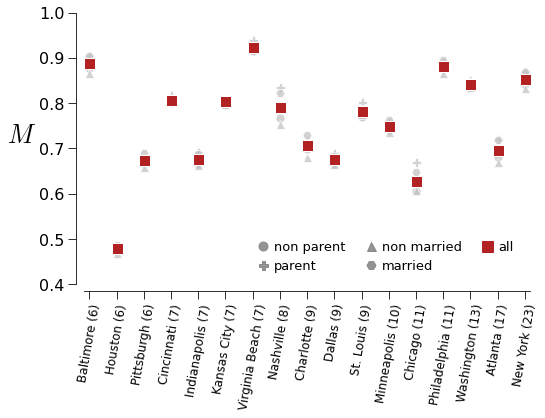

In [29]:
# common variables

label_iter_pe = ['non parent', 'parent', 'non married', 'married', 'all']

label_marker_pe = ['o', 'P', '^', 'H', 's']

label_color_pe = ['silver', 'silver', 'silver', 'silver', 'firebrick']

label_zones = mysorter


# values of the x variable

valx = np.arange(len(label_zones))

valxt = np.arange(len(label_zones))
valxt[0] -= 0.2
valxt[-1] += 0.2

# creating the figure

fig, ax = plt.subplots(figsize=(8,5))


# iterating over the data types except for the last (ALL)
for il in range(len(label_iter_pe[:-1])):
    l = label_iter_pe[il]
    m = label_marker_pe[il]
    c = label_color_pe[il]
    
    valy = diff_mobility_entropy[l]

    plt.plot(valx, valy, markersize=9, label = l,\
                 marker=m, lw = 1.25, ls='None', markeredgecolor='w',\
                 color=c, zorder=1, alpha=0.7)


# iterating over the last case (ALL)    
    
m = label_marker_pe[-1]        
l = label_iter_pe[-1]
c = label_color_pe[-1]

valy = diff_mobility_entropy[l]

plt.plot(valx, valy, markersize=11, label = l,\
             marker=m, lw = 2.5, ls='None',markeredgecolor='w',\
             color=c, zorder=3, alpha=1)


# legend
leg = plt.legend(ncol=3, frameon=False, fontsize=13,\
                 handlelength=0, bbox_to_anchor=(16.0,0.4), loc='lower right',\
                 bbox_transform=ax.transData)

for k in range(len(leg.legendHandles)-1):
    legobj = leg.legendHandles[k]
    legobj.set_color('grey')
    legobj.set_alpha(0.85)
    legobj.set_markeredgecolor(None)

legobj = leg.legendHandles[-1]
legobj.set_color('firebrick')
legobj.set_alpha(1)
legobj.set_markeredgecolor(None)
    
    
# spines & etc.

ax.spines[['right', 'top']].set_visible(False)

ax.spines.left.set_position(('data', -0.5))
ax.spines.bottom.set_position(('data', 0.385))


# ticks
ax.set_xticks(valxt)
ax.tick_params(axis='both', which='major',length=8, direction='out')
ax.tick_params(axis='x', which='major', labelsize=12)
ax.tick_params(axis='y', which='major', labelsize=16)
ax.set_xticklabels(label_zones, rotation=80, ha='center')

plt.ylim(0.4,1.0)
plt.xlim(-0.2,16.2)

plt.ylabel(r"$M$", fontsize=26, rotation='horizontal', labelpad=17)

ax.set_clip_on(False)

# saving figure

plt.savefig(figoutdir+'entropy-mobility-travellers-all_areas.svg', bbox_inches='tight')

plt.show()

### Fig. 2(c) -- Cost and diversity differences for MARRIED

In [30]:
diff_mobility_entropy.sort_values(by='MET2013_LABEL')['ZONE_LABEL']
#l1 = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['diff_marriage']
#l2 = diff_mobility_cost.sort_values(by='MET2013_LABEL')['diff_marriage']

0           Atlanta (17)
1          Baltimore (6)
2          Charlotte (9)
3           Chicago (11)
4         Cincinnati (7)
5             Dallas (9)
6            Houston (6)
7       Indianapolis (7)
8        Kansas City (7)
9       Minneapolis (10)
10         Nashville (8)
11         New York (23)
12     Philadelphia (11)
13        Pittsburgh (6)
14         St. Louis (9)
15    Virginia Beach (7)
16       Washington (13)
Name: ZONE_LABEL, dtype: object

In [31]:
diff_mobility_entropy.sort_values(by='MET2013_LABEL')

,MET2013_LABEL,all,married,non parent,non married,parent,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
0,"Atlanta-Sandy Springs-Roswell, GA",0.696735,0.718670,0.682015,0.670089,0.720493,17,Atlanta (17),0.038478,0.048581
1,"Baltimore-Columbia-Towson, MD",0.888574,0.905092,0.878618,0.865846,0.905301,6,Baltimore (6),0.026683,0.039246
2,"Charlotte-Concord-Gastonia, NC-SC",0.706791,0.728845,0.698528,0.680281,0.719459,9,Charlotte (9),0.020931,0.048564
3,"Chicago-Naperville-Elgin, IL-IN-WI",0.629121,0.647095,0.606010,0.609257,0.669781,11,Chicago (11),0.063771,0.037838
4,"Cincinnati, OH-KY-IN",0.807004,0.807721,0.800202,0.805485,0.818012,7,Cincinnati (7),0.017810,0.002236
5,"Dallas-Fort Worth-Arlington, TX",0.676382,0.683988,0.666751,0.666804,0.690395,9,Dallas (9),0.023644,0.017184
6,"Houston-The Woodlands-Sugar Land, TX",0.480124,0.487553,0.477046,0.470312,0.484359,6,Houston (6),0.007313,0.017241
7,"Indianapolis-Carmel-Anderson, IN",0.677443,0.687772,0.666820,0.662727,0.692140,7,Indianapolis (7),0.025320,0.025045
8,"Kansas City, MO-KS",0.803965,0.808025,0.806773,0.797507,0.797059,7,Kansas City (7),-0.009715,0.010518
9,"Minneapolis-St. Paul-Bloomington, MN-WI",0.750603,0.762616,0.741411,0.735375,0.761490,10,Minneapolis (10),0.020079,0.027241


> **Note — 4 versions of Fig. 2(c) [married] follow, all saving `diff_cost-diff_diversity-marriage.svg`.** They are iterations of the same panel; keep the one you submitted and delete the rest.

In [32]:
rescale_pop = 0

vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['diff_marriage']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['diff_marriage']

#population['size'] = np.square(np.log10(population['INDIVIDUAL_EXPANSION'])*2.5)
population['size'] = 0.05*np.sqrt(population['INDIVIDUAL_EXPANSION']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop

sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)


fig, ax = plt.subplots(figsize=(10,7))

# horizontal line
plt.plot([-0.05, 0.1],[0., 0.], ls='--', dashes=(10,4),\
         lw=2.5, color='firebrick', zorder=1)

# vertical line
plt.plot([0., 0.], [-0.1, 0.1], ls='--', dashes=(10,4),\
         lw=2.5, color='firebrick', zorder=1)


# coloring the areas
rect1 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, 0.1,
                        facecolor = colors['non married'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))

rect2 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, -0.1,
                        facecolor = colors['married'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))


# points
plt.scatter(vx, vy, s=sizes, marker='o', color='darkslategray', edgecolors='w',\
            linewidths=0.75, alpha=1, zorder=2)


# city labels
labels = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['ZONE_LABEL']

for elem in zip(vx,vy,labels):
    if elem[1] >= 0:
        mytext = ax.text(elem[0],elem[1]+0.0035,elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=12)
    else:
        mytext = ax.text(elem[0],elem[1]-0.005,elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=12)
        
    
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.35, foreground='w'),
                   path_effects.Normal()])


# text decorations
# mytext1 = ax.text(0.077,0.077,'Best for non married', ha='right', va='top',\
#                      color= colors['non married'],
#                      zorder=3, fontsize=20, fontweight='bold'
#                  )    

# mytext1.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['non married']),
#                        path_effects.Normal()])


# mytext2 = ax.text(0.077,-0.037,'Best for married', ha='right', va='bottom',\
#                      color= colors['married'],
#                      zorder=3, fontsize=20, fontweight='bold'
#                  )

# mytext2.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['married']),
#                        path_effects.Normal()])


plt.xlim(-0.02, 0.08)
plt.ylim(-0.04, 0.08)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='both',which='major',length=0, labelsize=20, pad=6)
ax.tick_params(axis='x',which='major', pad=12)

#plt.xlabel("Amenities diversity difference between\n people married and not married")
plt.xlabel(r"$\Delta M_M$", fontsize=37)
plt.ylabel(r"$\Delta C_M$", fontsize=37)

ax.spines[['right', 'left', 'top', 'bottom']].set_color('darkgrey')

plt.tight_layout()

# plt.savefig(figoutdir+'diff_cost-diff_diversity-marriage.svg', bbox_inches='tight')
plt.show()

NameError: name 'population' is not defined

In [33]:
sizes = population.sort_values(by='MET2013_LABEL')['density'].astype(float)
diff_mobility_entropy['density']=sizes
diff_mobility_entropy.sort_values(by='MET2013_LABEL')[['all','density']].corr(method='spearman')

NameError: name 'population' is not defined

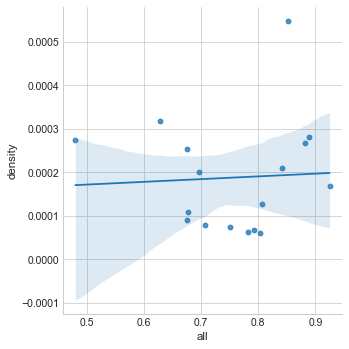

In [34]:
sns.lmplot(data=diff_mobility_entropy.sort_values(by='MET2013_LABEL')[['all','density']], x='all', y='density')

In [35]:
population.head()

,MET2013_LABEL,INDIVIDUAL_EXPANSION,total_area,density,size
0,"Atlanta-Sandy Springs-Roswell, GA",5996700,2.989262e+10,0.000201,501.520039
1,"Baltimore-Columbia-Towson, MD",2749210,9.802878e+09,0.000280,701.123209
2,"Charlotte-Concord-Gastonia, NC-SC",2649709,3.384993e+10,0.000078,195.695309
3,"Chicago-Naperville-Elgin, IL-IN-WI",9408177,2.957570e+10,0.000318,795.262371
4,"Cincinnati, OH-KY-IN",2150810,1.701852e+10,0.000126,315.951427


In [36]:
sizes = population.sort_values(by='MET2013_LABEL')['density'].astype(float)
diff_mobility_cost['density']=sizes
diff_mobility_cost.sort_values(by='MET2013_LABEL')[['All','density']].corr(method='spearman')

,All,density
All,1.000000,0.742647
density,0.742647,1.000000


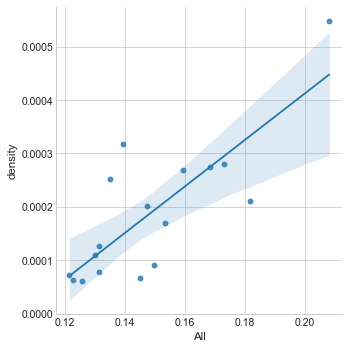

In [37]:
sns.lmplot(data=diff_mobility_cost.sort_values(by='MET2013_LABEL')[['All','density']], x='All', y='density')

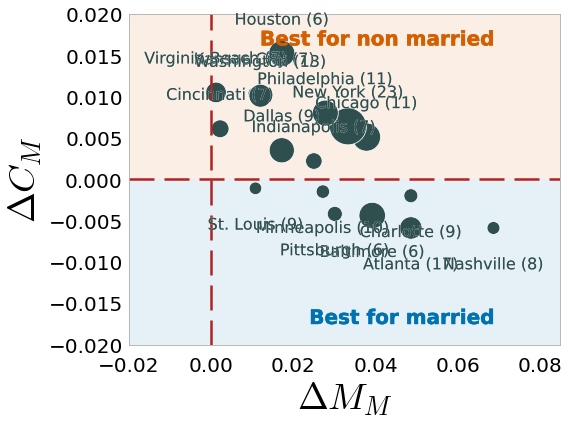

In [38]:
rescale_pop = 0

vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['diff_marriage']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['diff_marriage']

#population['size'] = np.square(np.log10(population['INDIVIDUAL_EXPANSION'])*2.5)
population['size'] = 0.3*np.sqrt(population['INDIVIDUAL_EXPANSION']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop

sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)


fig, ax = plt.subplots(figsize=(8,6))




# coloring the areas
rect1 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, 0.1,
                        facecolor = colors['non married'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))

rect2 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, -0.1,
                        facecolor = colors['married'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))


# points
plt.scatter(vx, vy, s=sizes, marker='o', color='darkslategray', edgecolors='w',\
            linewidths=0.75, alpha=1, zorder=2)


# city labels
labels = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['ZONE_LABEL']

for elem in zip(vx,vy,labels):
    if elem[1] >= 0:
        mytext = ax.text(elem[0],elem[1]+0.0035,elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    else:
        mytext = ax.text(elem[0],elem[1]-0.005,elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
        
    
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.35, foreground='w'),
                   path_effects.Normal()])


# text decorations
mytext1 = ax.text(0.069,0.018,'Best for non married', ha='right', va='top',\
                     color= colors['non married'],
                     zorder=3, fontsize=20, fontweight='bold'
                 )    

mytext1.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['non married']),
                       path_effects.Normal()])


mytext2 = ax.text(0.069,-0.018,'Best for married', ha='right', va='bottom',\
                     color= colors['married'],
                     zorder=3, fontsize=20, fontweight='bold'
                 )

mytext2.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['married']),
                       path_effects.Normal()])

x_l0 =-0.02
x_l1 = 0.085
plt.xlim(x_l0, x_l1)
plt.ylim(x_l0, 0.02)

# horizontal line
plt.axhline(y=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")
plt.axvline(x=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='both',which='major',length=0, labelsize=20, pad=6)
ax.tick_params(axis='x',which='major', pad=12)

#plt.xlabel("Amenities diversity difference between\n people married and not married")
plt.xlabel(r"$\Delta M_M$", fontsize=37)
plt.ylabel(r"$\Delta C_M$", fontsize=37)

ax.spines[['right', 'left', 'top', 'bottom']].set_color('darkgrey')

plt.tight_layout()

# plt.savefig(figoutdir+'diff_cost-diff_diversity-marriage.svg', bbox_inches='tight')
plt.show()

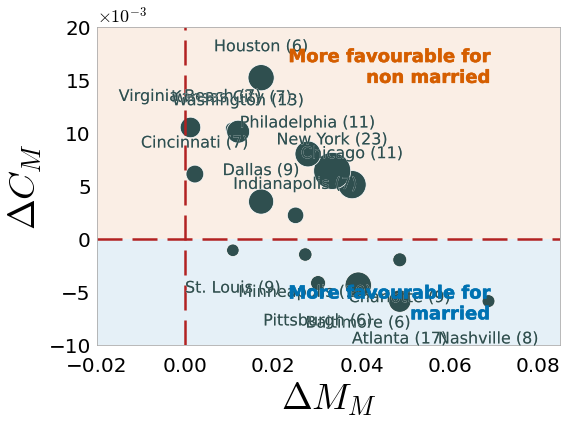

In [39]:
rescale_pop = 0
vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['diff_marriage']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['diff_marriage']

# Multiply only y values by 1000 for display
vy_display = vy * 1000

population['size'] = 0.3*np.sqrt(population['INDIVIDUAL_EXPANSION']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop
sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)

fig, ax = plt.subplots(figsize=(8,6))

# Coloring the areas (adjusted for new scale)
rect1 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, 100,
                        facecolor = colors['non married'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))
rect2 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, -100,
                        facecolor = colors['married'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))

# Points
plt.scatter(vx, vy_display, s=sizes, marker='o', color='darkslategray', edgecolors='w',\
            linewidths=0.75, alpha=1, zorder=2)

# City labels
labels = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['ZONE_LABEL']
for elem in zip(vx, vy_display, labels):
    if elem[1] >= 0:
        mytext = ax.text(elem[0], elem[1]+2.5, elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    else:
        mytext = ax.text(elem[0], elem[1]-4, elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
        
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.35, foreground='w'),
                   path_effects.Normal()])

# Text decorations - changed "Best for" to "More favorable for"
mytext1 = ax.text(0.069, 18, 'More favourable for\nnon married', ha='right', va='top',\
                     color= colors['non married'],
                     zorder=3, fontsize=18, fontweight='bold'
                 )    
mytext1.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['non married']),
                       path_effects.Normal()])
mytext2 = ax.text(0.069, -8, 'More favourable for\nmarried', ha='right', va='bottom',\
                     color= colors['married'],
                     zorder=3, fontsize=18, fontweight='bold'
                 )
mytext2.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['married']),
                       path_effects.Normal()])

# Axis limits
x_l0 = -0.02
x_l1 = 0.085
plt.xlim(x_l0, x_l1)
plt.ylim(-10, 20)  # Set y-axis boundaries as requested

# Horizontal and vertical lines
plt.axhline(y=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")
plt.axvline(x=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='both', which='major', length=0, labelsize=20, pad=6)
ax.tick_params(axis='x', which='major', pad=12)

# Updated axis labels - no scaling for x-axis, scaling only for y-axis
plt.xlabel(r"$\Delta M_M$", fontsize=37)
plt.ylabel(r"$\Delta C_M$", fontsize=37)
ax.text(-0.02, 20, r'$\times 10^{-3}$', fontsize=18, ha='left', va='bottom')

ax.spines[['right', 'left', 'top', 'bottom']].set_color('darkgrey')
plt.tight_layout()
plt.savefig(figoutdir+'diff_cost-diff_diversity-marriage.svg', bbox_inches='tight')
plt.show()

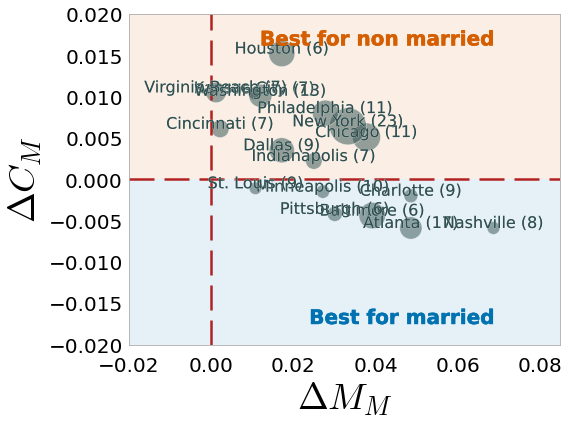

In [40]:
rescale_pop = 0

vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['diff_marriage']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['diff_marriage']

#population['size'] = np.square(np.log10(population['INDIVIDUAL_EXPANSION'])*2.5)
population['size'] = 0.03*np.sqrt(population['INDIVIDUAL_EXPANSION']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop

sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)


fig, ax = plt.subplots(figsize=(8,6))




# coloring the areas
rect1 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, 0.1,
                        facecolor = colors['non married'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))

rect2 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, -0.1,
                        facecolor = colors['married'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))


# points
plt.scatter(vx, vy, s=sizes, marker='o', color='darkslategray', edgecolors='w',\
            linewidths=0.75, alpha=0.5, zorder=2)


# city labels
labels = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['ZONE_LABEL']

for elem in zip(vx,vy,labels):
    if elem[1] >= 0:
        mytext = ax.text(elem[0],elem[1],elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    else:
        mytext = ax.text(elem[0],elem[1],elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
        
    
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.35, foreground='w'),
                   path_effects.Normal()])


# text decorations
mytext1 = ax.text(0.069,0.018,'Best for non married', ha='right', va='top',\
                     color= colors['non married'],
                     zorder=3, fontsize=20, fontweight='bold'
                 )    

mytext1.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['non married']),
                       path_effects.Normal()])


mytext2 = ax.text(0.069,-0.018,'Best for married', ha='right', va='bottom',\
                     color= colors['married'],
                     zorder=3, fontsize=20, fontweight='bold'
                 )

mytext2.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['married']),
                       path_effects.Normal()])

x_l0 =-0.02
x_l1 = 0.085
plt.xlim(x_l0, x_l1)
plt.ylim(x_l0, 0.02)

# horizontal line
plt.axhline(y=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")
plt.axvline(x=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='both',which='major',length=0, labelsize=20, pad=6)
ax.tick_params(axis='x',which='major', pad=12)

#plt.xlabel("Amenities diversity difference between\n people married and not married")
plt.xlabel(r"$\Delta M_M$", fontsize=37)
plt.ylabel(r"$\Delta C_M$", fontsize=37)

ax.spines[['right', 'left', 'top', 'bottom']].set_color('darkgrey')

plt.tight_layout()

# plt.savefig(figoutdir+'diff_cost-diff_diversity-marriage.svg', bbox_inches='tight')
plt.show()

### Fig. 2(d) -- Cost and diversity differences for PARENTS

> **Note — 3 versions of Fig. 2(d) [parents] follow, all saving `diff_cost-diff_diversity-parenthood.svg`.** They are iterations of the same panel; keep the one you submitted and delete the rest.

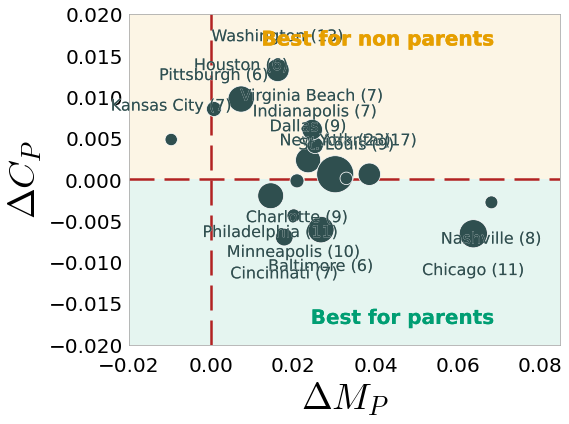

In [41]:
rescale_pop = 0

vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['diff_parenthood']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['diff_parenthood']

population['size'] = 0.3*np.sqrt(population['INDIVIDUAL_EXPANSION']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop

sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)


fig, ax = plt.subplots(figsize=(8,6))

# horizontal line
plt.axhline(y=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")
plt.axvline(x=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")
# plt.plot([-0.05, 0.1],[0., 0.], ls='--', dashes=(10,4),\
#          lw=2.5, color='firebrick', zorder=1)

# # vertical line
# plt.plot([0., 0.], [-0.05, 0.1], ls='--', dashes=(10,4),\
#          lw=2.5, color='firebrick', zorder=1)


# coloring the areas
rect1 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, 0.1,
                        facecolor = colors['non parent'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))

rect2 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, -0.1,
                        facecolor = colors['parent'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))


# points
plt.scatter(vx, vy, s=sizes, marker='o', color='darkslategray', edgecolors='w',\
            linewidths=0.75, alpha=1, zorder=2)


# city labels
labels = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['ZONE_LABEL']

for elem in zip(vx,vy,labels):
    if elem[1] >= 0:
        mytext = ax.text(elem[0],elem[1]+0.0035,elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    else:
        mytext = ax.text(elem[0],elem[1]-0.005,elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.35, foreground='w'),
                   path_effects.Normal()])


# text decorations
mytext1 = ax.text(0.069,0.018,'Best for non parents', ha='right', va='top',\
                     color= colors['non parent'],
                     zorder=3, fontsize=20, fontweight='bold'
                 )    

mytext1.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['non parent']),
                       path_effects.Normal()])


mytext2 = ax.text(0.069,-0.018,'Best for parents', ha='right', va='bottom',\
                     color= colors['parent'],
                     zorder=3, fontsize=20, fontweight='bold'
                 )

mytext2.set_path_effects([path_effects.Stroke(linewidth=0.0, foreground=colors['parent']),
                       path_effects.Normal()])



# plt.xlim(-0.02, 0.08)
# plt.ylim(-0.04, 0.08)

x_l0 =-0.02
x_l1 = 0.085
plt.xlim(x_l0, x_l1)
plt.ylim(x_l0, 0.02)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='both',which='major',length=0, labelsize=20, pad=6)
ax.tick_params(axis='x',which='major', pad=12)

#plt.xlabel("Amenities diversity difference between\n people married and not married")
plt.xlabel(r"$\Delta M_P$", fontsize=37)
plt.ylabel(r"$\Delta C_P$", fontsize=37)

ax.spines[['right', 'left', 'top', 'bottom']].set_color('darkgrey')

plt.tight_layout()

plt.savefig(figoutdir+'diff_cost-diff_diversity-parenthood.svg', bbox_inches='tight')
plt.show()

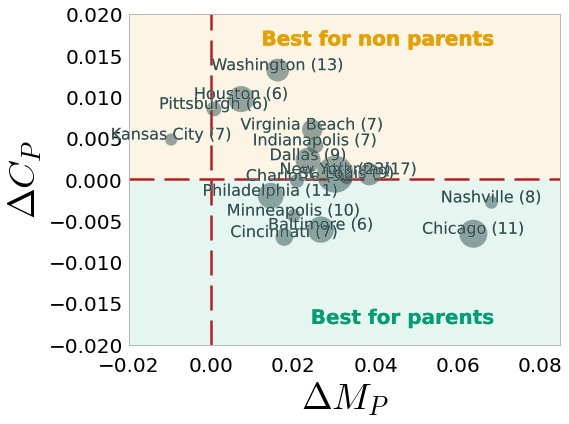

In [42]:
rescale_pop = 0

vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['diff_parenthood']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['diff_parenthood']

population['size'] = 0.03*np.sqrt(population['INDIVIDUAL_EXPANSION']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop

sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)


fig, ax = plt.subplots(figsize=(8,6))

# horizontal line
plt.axhline(y=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")
plt.axvline(x=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")
# plt.plot([-0.05, 0.1],[0., 0.], ls='--', dashes=(10,4),\
#          lw=2.5, color='firebrick', zorder=1)

# # vertical line
# plt.plot([0., 0.], [-0.05, 0.1], ls='--', dashes=(10,4),\
#          lw=2.5, color='firebrick', zorder=1)


# coloring the areas
rect1 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, 0.1,
                        facecolor = colors['non parent'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))

rect2 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, -0.1,
                        facecolor = colors['parent'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))


# points
plt.scatter(vx, vy, s=sizes, marker='o', color='darkslategray', edgecolors='w',\
            linewidths=0.2, alpha=0.5, zorder=2)


# city labels
labels = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['ZONE_LABEL']

for elem in zip(vx,vy,labels):
    if elem[1] >= 0:
        mytext = ax.text(elem[0],elem[1],elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    else:
        mytext = ax.text(elem[0],elem[1],elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.35, foreground='w'),
                   path_effects.Normal()])


# text decorations
mytext1 = ax.text(0.069,0.018,'Best for non parents', ha='right', va='top',\
                     color= colors['non parent'],
                     zorder=3, fontsize=20, fontweight='bold'
                 )    

mytext1.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['non parent']),
                       path_effects.Normal()])


mytext2 = ax.text(0.069,-0.018,'Best for parents', ha='right', va='bottom',\
                     color= colors['parent'],
                     zorder=3, fontsize=20, fontweight='bold'
                 )

mytext2.set_path_effects([path_effects.Stroke(linewidth=0.0, foreground=colors['parent']),
                       path_effects.Normal()])



# plt.xlim(-0.02, 0.08)
# plt.ylim(-0.04, 0.08)

x_l0 =-0.02
x_l1 = 0.085
plt.xlim(x_l0, x_l1)
plt.ylim(x_l0, 0.02)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='both',which='major',length=0, labelsize=20, pad=6)
ax.tick_params(axis='x',which='major', pad=12)

#plt.xlabel("Amenities diversity difference between\n people married and not married")
plt.xlabel(r"$\Delta M_P$", fontsize=37)
plt.ylabel(r"$\Delta C_P$", fontsize=37)

ax.spines[['right', 'left', 'top', 'bottom']].set_color('darkgrey')

plt.tight_layout()

# plt.savefig(figoutdir+'diff_cost-diff_diversity-parenthood.svg', bbox_inches='tight')
plt.show()

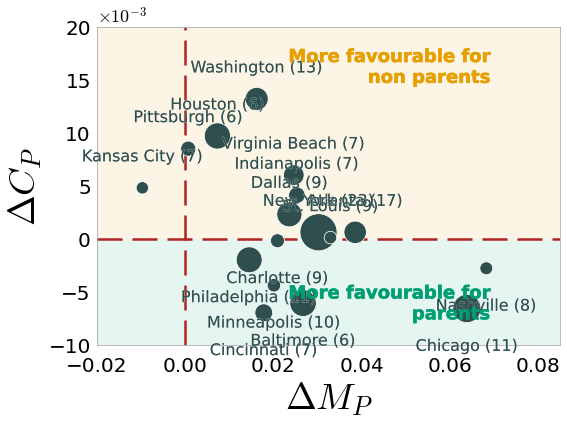

In [43]:
rescale_pop = 0
vx = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['diff_parenthood']
vy = diff_mobility_cost.sort_values(by='MET2013_LABEL')['diff_parenthood']

# Multiply only y values by 1000 for display
vy_display = vy * 1000

population['size'] = 0.3*np.sqrt(population['INDIVIDUAL_EXPANSION']/np.pi)
population['size'] = 2500000*population['density']
population['size'] -= rescale_pop
sizes = population.sort_values(by='MET2013_LABEL')['size'].astype(float)

fig, ax = plt.subplots(figsize=(8,6))

# Horizontal and vertical lines
plt.axhline(y=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")
plt.axvline(x=0, color="firebrick", dashes=(10,4), lw=2.5, linestyle="--")

# Coloring the areas (adjusted for new scale)
rect1 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, 100,
                        facecolor = colors['non parent'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))
rect2 = ax.add_patch(Rectangle((-0.05, 0.0), 0.2, -100,
                        facecolor = colors['parent'],
                        linestyle= None, 
                        fill=True, clip_on=True,
                        alpha=0.1, zorder=0))

# Points
plt.scatter(vx, vy_display, s=sizes, marker='o', color='darkslategray', edgecolors='w',\
            linewidths=0.75, alpha=1, zorder=2)

# City labels
labels = diff_mobility_entropy.sort_values(by='MET2013_LABEL')['ZONE_LABEL']
for elem in zip(vx, vy_display, labels):
    if elem[1] >= 0:
        mytext = ax.text(elem[0], elem[1]+2.5, elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    else:
        mytext = ax.text(elem[0], elem[1]-4, elem[2], ha='center',\
                         color='darkslategray',\
                         zorder=3, fontsize=16)
    
    mytext.set_path_effects([path_effects.Stroke(linewidth=0.35, foreground='w'),
                   path_effects.Normal()])

# Text decorations - changed "Best for" to "More favorable for"
mytext1 = ax.text(0.069, 18, 'More favourable for\nnon parents', ha='right', va='top',\
                     color= colors['non parent'],
                     zorder=3, fontsize=18, fontweight='bold'
                 )    
mytext1.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['non parent']),
                       path_effects.Normal()])
mytext2 = ax.text(0.069, -8, 'More favourable for\nparents', ha='right', va='bottom',\
                     color= colors['parent'],
                     zorder=3, fontsize=18, fontweight='bold'
                 )
mytext2.set_path_effects([path_effects.Stroke(linewidth=0.5, foreground=colors['parent']),
                       path_effects.Normal()])

# Axis limits
x_l0 = -0.02
x_l1 = 0.085
plt.xlim(x_l0, x_l1)
plt.ylim(-10, 20)  # Set y-axis boundaries as requested

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
ax.tick_params(axis='both', which='major', length=0, labelsize=20, pad=6)
ax.tick_params(axis='x', which='major', pad=12)

# Updated axis labels without scaling notation
plt.xlabel(r"$\Delta M_P$", fontsize=37)
plt.ylabel(r"$\Delta C_P$", fontsize=37)

# Add scale annotation on y-axis
ax.text(-0.02, 20, r'$\times 10^{-3}$', fontsize=18, ha='left', va='bottom')

ax.spines[['right', 'left', 'top', 'bottom']].set_color('darkgrey')
plt.tight_layout()
plt.savefig(figoutdir+'diff_cost-diff_diversity-parenthood.svg', bbox_inches='tight')
plt.show()

In [44]:
diff_mobility_entropy.columns

Index(['MET2013_LABEL', 'all', 'married', 'non parent', 'non married',
       'parent', 'n_zones', 'ZONE_LABEL', 'diff_parenthood', 'diff_marriage'],
      dtype='object')

In [45]:
diff_mobility_entropy.rename(columns={'With Children':'parent','No Children':'non parent','Married':'married','Not Married':'non married','All':'all'}, inplace=True)

In [46]:
print(diff_mobility_entropy.sort_values(by='n_zones')[['ZONE_LABEL','all','parent', 'non parent', 'diff_parenthood',\
'married', 'non married','diff_marriage']].to_latex(index=False, float_format="%.4f"))

\begin{tabular}{lrrrrrrr}
\toprule
ZONE_LABEL & all & parent & non parent & diff_parenthood & married & non married & diff_marriage \\
\midrule
Baltimore (6) & 0.8886 & 0.9053 & 0.8786 & 0.0267 & 0.9051 & 0.8659 & 0.0392 \\
Houston (6) & 0.4801 & 0.4844 & 0.4770 & 0.0073 & 0.4876 & 0.4703 & 0.0173 \\
Pittsburgh (6) & 0.6756 & 0.6751 & 0.6745 & 0.0006 & 0.6892 & 0.6591 & 0.0301 \\
Cincinnati (7) & 0.8070 & 0.8180 & 0.8002 & 0.0178 & 0.8077 & 0.8055 & 0.0022 \\
Indianapolis (7) & 0.6775 & 0.6921 & 0.6668 & 0.0253 & 0.6878 & 0.6628 & 0.0250 \\
Kansas City (7) & 0.8040 & 0.7971 & 0.8068 & -0.0097 & 0.8080 & 0.7975 & 0.0105 \\
Virginia Beach (7) & 0.9251 & 0.9405 & 0.9159 & 0.0246 & 0.9254 & 0.9242 & 0.0012 \\
Nashville (8) & 0.7926 & 0.8347 & 0.7665 & 0.0682 & 0.8221 & 0.7534 & 0.0687 \\
St. Louis (9) & 0.7825 & 0.8027 & 0.7697 & 0.0329 & 0.7869 & 0.7761 & 0.0108 \\
Charlotte (9) & 0.7068 & 0.7195 & 0.6985 & 0.0210 & 0.7288 & 0.6803 & 0.0486 \\
Dallas (9) & 0.6764 & 0.6904 & 0.6667 & 0.023

In [47]:
diff_mobility_cost.rename(columns={'With Children':'parent','No Children':'non parent','Married':'married','Not Married':'non married','All':'all'}, inplace=True)

In [48]:
diff_mobility_cost.head(2)

,MET2013_LABEL,all,married,non parent,non married,parent,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
0,"Atlanta-Sandy Springs-Roswell, GA",0.147234,0.138349,0.177463,0.152883,0.160223,17,Atlanta (17),-0.017239,-0.014534
1,"Baltimore-Columbia-Towson, MD",0.172832,0.164445,0.181724,0.180161,0.182343,6,Baltimore (6),0.000619,-0.015716


In [49]:
print(diff_mobility_cost.sort_values(by='n_zones')[['ZONE_LABEL','all',\
        'parent', 'non parent', 'diff_parenthood',\
        'married', 'non married','diff_marriage'\
            ]].to_latex(index=False, float_format="%.4F"))

\begin{tabular}{lrrrrrrr}
\toprule
ZONE_LABEL & all & parent & non parent & diff_parenthood & married & non married & diff_marriage \\
\midrule
Baltimore (6) & 0.1728 & 0.1823 & 0.1817 & 0.0006 & 0.1644 & 0.1802 & -0.0157 \\
Houston (6) & 0.1684 & 0.1833 & 0.1583 & 0.0249 & 0.1527 & 0.1375 & 0.0152 \\
Pittsburgh (6) & 0.1495 & 0.1586 & 0.1438 & 0.0149 & 0.1437 & 0.1548 & -0.0111 \\
Kansas City (7) & 0.1258 & 0.1265 & 0.1233 & 0.0032 & 0.1241 & 0.1293 & -0.0051 \\
Cincinnati (7) & 0.1313 & 0.1303 & 0.1511 & -0.0209 & 0.1430 & 0.1333 & 0.0097 \\
Indianapolis (7) & 0.1299 & 0.1227 & 0.1179 & 0.0048 & 0.1334 & 0.1236 & 0.0098 \\
Virginia Beach (7) & 0.1532 & 0.1376 & 0.1345 & 0.0031 & 0.1583 & 0.1475 & 0.0108 \\
Nashville (8) & 0.1451 & 0.1489 & 0.1428 & 0.0061 & 0.1446 & 0.1436 & 0.0010 \\
Charlotte (9) & 0.1313 & 0.1301 & 0.1322 & -0.0021 & 0.1322 & 0.1291 & 0.0031 \\
Dallas (9) & 0.1349 & 0.1368 & 0.1397 & -0.0029 & 0.1492 & 0.1472 & 0.0019 \\
St. Louis (9) & 0.1228 & 0.1303 & 0.1260 & 

In [50]:
diff_mobility_cost['diff_parenthood']

0    -0.017239
1     0.000619
2    -0.002076
3    -0.017755
4    -0.020862
5    -0.002870
6     0.024938
7     0.004777
8     0.003159
9    -0.006613
10    0.006078
11   -0.006981
12    0.005693
13    0.014862
14    0.004237
15    0.003118
16   -0.003638
Name: diff_parenthood, dtype: float64

In [51]:
diff_mobility_cost['diff_marriage']>diff_mobility_cost['diff_parenthood']

0      True
1     False
2      True
3      True
4      True
5      True
6     False
7      True
8     False
9     False
10    False
11     True
12    False
13    False
14    False
15     True
16     True
dtype: bool

<Axes: >

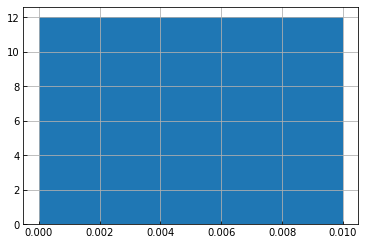

In [52]:
diff_mobility_cost['diff_parenthood'].abs().hist(bins=[0,0.01])

In [53]:
diff_mobility_cost[diff_mobility_cost['diff_parenthood'].abs()<0.001].sort_values(by='diff_parenthood')

,MET2013_LABEL,all,married,non parent,non married,parent,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
1,"Baltimore-Columbia-Towson, MD",0.172832,0.164445,0.181724,0.180161,0.182343,6,Baltimore (6),0.000619,-0.015716


In [54]:
diff_mobility_cost[(diff_mobility_cost['diff_parenthood'].abs()<0.005) & (diff_mobility_cost['diff_marriage'].abs()<0.005)]

,MET2013_LABEL,all,married,non parent,non married,parent,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
2,"Charlotte-Concord-Gastonia, NC-SC",0.131281,0.132186,0.132220,0.129119,0.130144,9,Charlotte (9),-0.002076,0.003067
5,"Dallas-Fort Worth-Arlington, TX",0.134851,0.149157,0.139674,0.147233,0.136805,9,Dallas (9),-0.002870,0.001924
16,"Washington-Arlington-Alexandria, DC-VA-MD-WV",0.181605,0.182019,0.211015,0.185477,0.207377,13,Washington (13),-0.003638,-0.003458


In [55]:
diff_mobility_cost[(diff_mobility_cost['diff_parenthood']<-0.001)].sort_values(by='diff_parenthood')

,MET2013_LABEL,all,married,non parent,non married,parent,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
4,"Cincinnati, OH-KY-IN",0.131327,0.143000,0.151124,0.133299,0.130262,7,Cincinnati (7),-0.020862,0.009701
3,"Chicago-Naperville-Elgin, IL-IN-WI",0.139245,0.178054,0.143362,0.138465,0.125607,11,Chicago (11),-0.017755,0.039589
0,"Atlanta-Sandy Springs-Roswell, GA",0.147234,0.138349,0.177463,0.152883,0.160223,17,Atlanta (17),-0.017239,-0.014534
11,"New York-Newark-Jersey City, NY-NJ-PA",0.208065,0.208385,0.210547,0.185435,0.203566,23,New York (23),-0.006981,0.022950
9,"Minneapolis-St. Paul-Bloomington, MN-WI",0.121513,0.114085,0.124332,0.130099,0.117718,10,Minneapolis (10),-0.006613,-0.016014
16,"Washington-Arlington-Alexandria, DC-VA-MD-WV",0.181605,0.182019,0.211015,0.185477,0.207377,13,Washington (13),-0.003638,-0.003458
5,"Dallas-Fort Worth-Arlington, TX",0.134851,0.149157,0.139674,0.147233,0.136805,9,Dallas (9),-0.002870,0.001924
2,"Charlotte-Concord-Gastonia, NC-SC",0.131281,0.132186,0.132220,0.129119,0.130144,9,Charlotte (9),-0.002076,0.003067


In [56]:
diff_mobility_cost[(diff_mobility_cost['diff_marriage']<-0.001)].sort_values(by='diff_marriage')

,MET2013_LABEL,all,married,non parent,non married,parent,n_zones,ZONE_LABEL,diff_parenthood,diff_marriage
14,"St. Louis, MO-IL",0.122757,0.119596,0.126029,0.137835,0.130267,9,St. Louis (9),0.004237,-0.018239
9,"Minneapolis-St. Paul-Bloomington, MN-WI",0.121513,0.114085,0.124332,0.130099,0.117718,10,Minneapolis (10),-0.006613,-0.016014
1,"Baltimore-Columbia-Towson, MD",0.172832,0.164445,0.181724,0.180161,0.182343,6,Baltimore (6),0.000619,-0.015716
0,"Atlanta-Sandy Springs-Roswell, GA",0.147234,0.138349,0.177463,0.152883,0.160223,17,Atlanta (17),-0.017239,-0.014534
13,"Pittsburgh, PA",0.149511,0.143703,0.143761,0.154846,0.158623,6,Pittsburgh (6),0.014862,-0.011143
8,"Kansas City, MO-KS",0.125763,0.124141,0.123297,0.129257,0.126456,7,Kansas City (7),0.003159,-0.005116
16,"Washington-Arlington-Alexandria, DC-VA-MD-WV",0.181605,0.182019,0.211015,0.185477,0.207377,13,Washington (13),-0.003638,-0.003458
12,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD",0.159448,0.157640,0.159306,0.159456,0.164999,11,Philadelphia (11),0.005693,-0.001816
